In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpi4py import MPI
from dolfinx import mesh, fem
from visualization_fct import *
from my_functions import create_quad_domain, assign_material
import pickle

In [2]:
# Define geometry
P0 = np.array([0, 0])
P1 = np.array([6, -1])
P2 = np.array([6, 2])
P3 = np.array([0, 3])
slope = (P1[1]-P0[1])/(P1[0]-P0[0])

nx = 120
nz = 60
T_end = 360 # end time [h]
t_obs = 0 # observation time [h]
filename = "../solutions/heterogeneous_" + str(T_end) + "h_nx" + str(nx) + "_nz" + str(nz) + ".pkl"

layer_params = {
    1: {"name": "loam", "alpha": 3.6, "N": 1.56, "theta_r": 0.078, "theta_s": 0.43, "Ks": 2.89e-6, "locator": lambda x: False},
    2: {"name": "sand", "alpha": 14.5, "N": 2.68, "theta_r": 0.045, "theta_s": 0.43, "Ks": 8.25e-5, "locator": lambda x: x[1] >= slope*x[0] + P3[1]/2 - 1e-14},
    3: {"name": "silt", "alpha": 1.6, "N": 1.37, "theta_r": 0.034, "theta_s": 0.46, "Ks": 6.94e-7, "locator": lambda x: x[1] < slope*x[0] + P3[1]/2 - 1e-14},
}

In [3]:
# Load solution
with open(filename, "rb") as f:
    data_Annika = pickle.load(f)
# Create domain
domain = create_quad_domain(MPI.COMM_WORLD, nx, nz, P0, P1, P2, P3, celltype=mesh.CellType.quadrilateral)
V = fem.functionspace(domain, ("CG", 1))
Q = fem.functionspace(domain, ("DG", 0))
h_w = fem.Function(V)
# Assign material properties
param_fct = assign_material(domain, Q, layer_params)
Ks = param_fct["Ks"]
alpha = param_fct["alpha"]
N = param_fct["N"]
theta_r = param_fct["theta_r"]
theta_s = param_fct["theta_s"]

In [29]:
np.round(np.array(data_Annika["times"][40])/3600)

np.float64(42.0)

In [30]:
t_obs = 40
h_w.x.array[:] = np.array(data_Annika["h_w"][t_obs])

# Evaluate solution
n = 60
grid, x_grid, z_grid = get_grid(P0, P1, P2, P3, n)
pressure_head = eval_fct_on_grid(grid, h_w, domain).reshape((n,n))
alpha_eval = eval_fct_on_grid(grid, alpha, domain).reshape((n,n))
N_eval = eval_fct_on_grid(grid, N, domain).reshape((n,n))
theta_r_eval = eval_fct_on_grid(grid, theta_r, domain).reshape((n,n))
theta_s_eval = eval_fct_on_grid(grid, theta_s, domain).reshape((n,n))
h_tot = pressure_head + z_grid
h_c = pressure_head * (pressure_head <= 0)
def S_e1(h_c, alpha, N):
    return (1 + (- alpha * h_c)**N)**((1 - N) / N)
theta_tot = theta_r_eval + (theta_s_eval - theta_r_eval)*S_e1(h_c.flatten(), alpha_eval.flatten(), N_eval.flatten()).reshape((n,n))

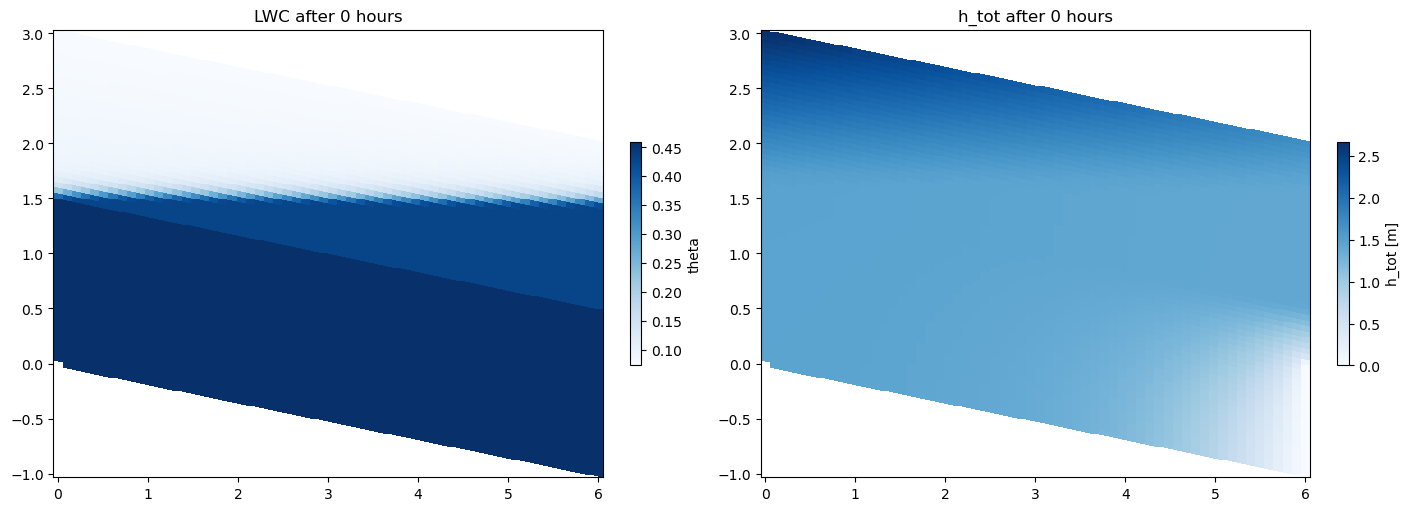

In [7]:
fig, ax = plt.subplots(1,2, layout="constrained", figsize=(14,5))
pmsh1 = ax[0].pcolormesh(x_grid, z_grid, theta_tot, cmap="Blues")
ax[0].set_title(f"LWC after {T_end/3600:.0f} hours")
cbar1 = fig.colorbar(pmsh1, ax=ax[0], shrink=0.5)
cbar1.set_label("theta")

pmsh2 = ax[1].pcolormesh(x_grid, z_grid, h_tot, cmap="Blues")
ax[1].set_title(f"h_tot after {T_end/3600:.0f} hours")
cbar2 = fig.colorbar(pmsh2, ax=ax[1], shrink=0.5)
cbar2.set_label("h_tot [m]")

In [8]:
# open pickle file and load
with open("Test_Annika_heterogen.pkl", "rb") as f:
    data = pickle.load(f)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [31]:
anne_x = data["X_plot"]
anne_z = data["Z_plot"]
anne_theta = data["theta_l_total"][42]
anne_h_tot = data["h_total"][42]
anne_h_c = data["h_c_total"][42]

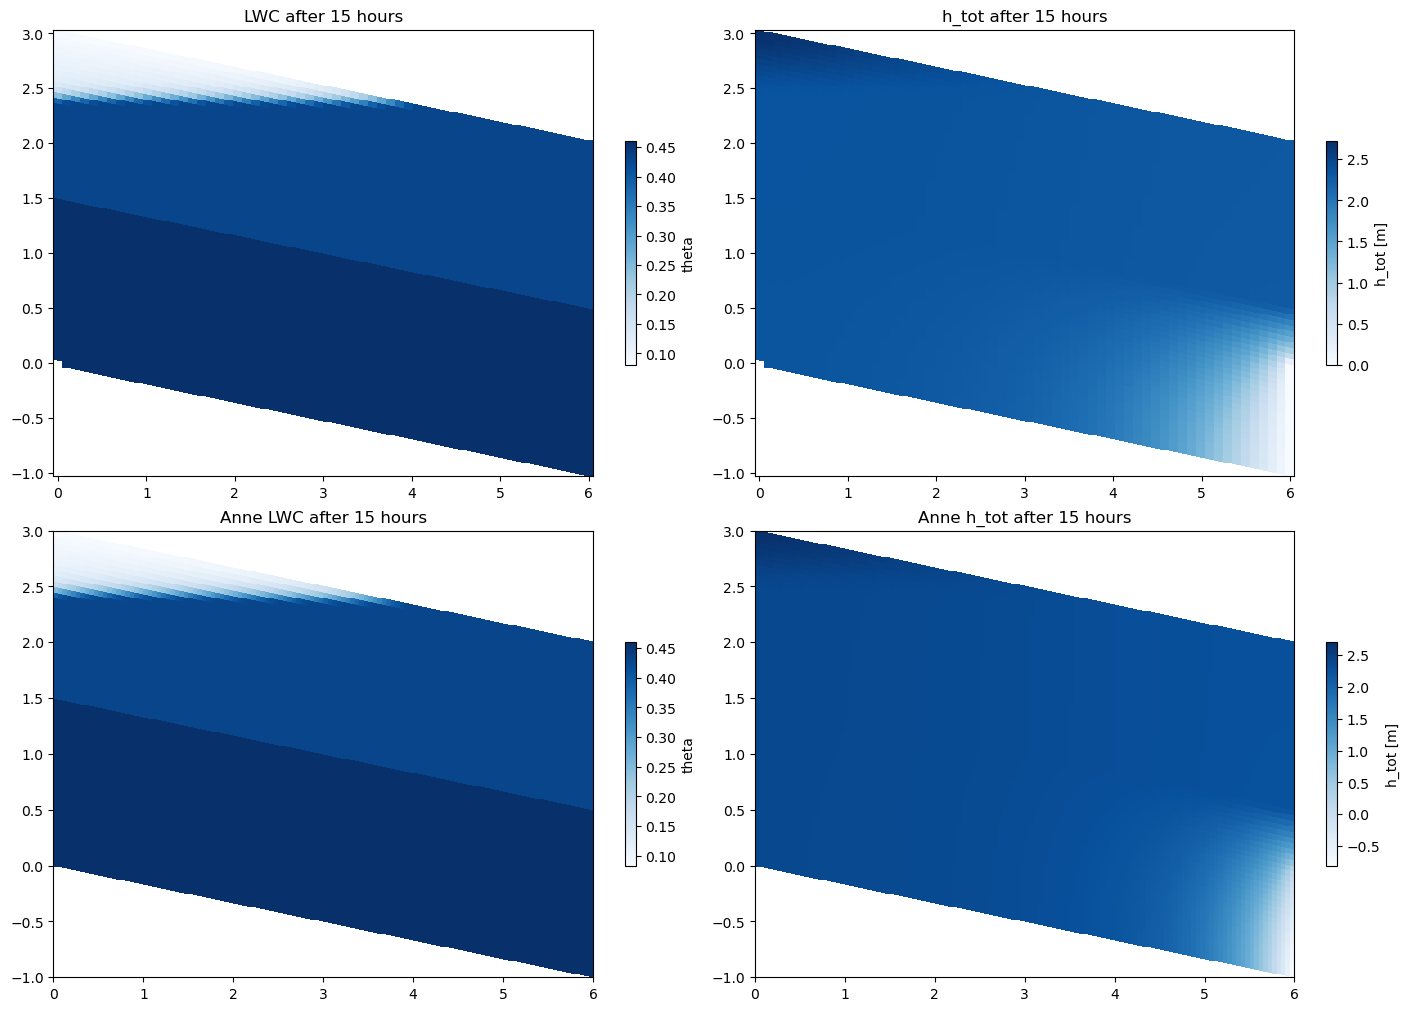

In [32]:
vmin_theta = np.min([np.nanmin(theta_tot), np.nanmin(anne_theta)])
vmin_h = np.min([np.nanmin(h_tot), np.nanmin(anne_h_tot)])

vmax_theta = np.max([np.nanmax(theta_tot), np.nanmax(anne_theta)])
vmax_h = np.max([np.nanmax(h_tot), np.nanmax(anne_h_tot)])

fig, ax = plt.subplots(2,2, layout="constrained", figsize=(14,10))
pmsh1 = ax[0, 0].pcolormesh(x_grid, z_grid, theta_tot, cmap="Blues")
ax[0, 0].set_title(f"LWC after 15 hours")
cbar1 = fig.colorbar(pmsh1, ax=ax[0, 0], shrink=0.5)
cbar1.set_label("theta")

pmsh2 = ax[0, 1].pcolormesh(x_grid, z_grid, h_tot, cmap="Blues")
ax[0, 1].set_title(f"h_tot after 15 hours")
cbar2 = fig.colorbar(pmsh2, ax=ax[0, 1], shrink=0.5)
cbar2.set_label("h_tot [m]")

pmsh11 = ax[1, 0].pcolormesh(anne_x, anne_z, anne_theta, cmap="Blues", shading="flat")
ax[1, 0].set_title(f"Anne LWC after 15 hours")
cbar1 = fig.colorbar(pmsh11, ax=ax[1, 0], shrink=0.5)
cbar1.set_label("theta")

pmsh12 = ax[1, 1].pcolormesh(anne_x, anne_z, anne_h_tot, cmap="Blues", shading="flat")
ax[1, 1].set_title(f"Anne h_tot after 15 hours")
cbar2 = fig.colorbar(pmsh12, ax=ax[1, 1], shrink=0.5)
cbar2.set_label("h_tot [m]")

In [26]:
def get_grid1(P0, P1, P2, P3, nx, nz):
    """
    Generate a grid of points made up of four corner points.

    Args:
        P0 (np.array): x and y coordinates of the bottom-left corner point
        P1 (np.array): x and y coordinates of the bottom-right corner point
        P2 (np.array): x and y coordinates of the top-right corner point
        P3 (np.array): x and y coordinates of the top-left corner point
        n (int, optional): number of points in x- and z-direction. Defaults to 20.

    Returns:
        np.ndarray: list of 2D points of the grid, size (n*n, 2)
        np.ndarray: grid of x-coordinates, size (n, n)
        np.ndarray: grid of z-coordinates, size (n, n)
    """
    x_int = np.linspace(0, 1, nx)
    z_int = np.linspace(0, 1, nz)
    x_int, z_int = np.meshgrid(x_int, z_int)

    # Bilinear interpolation
    x_grid = (1 - x_int) * (1 - z_int) * P0[0] + x_int * (1 - z_int) * P1[0] + x_int * z_int * P2[0] + (1 - x_int) * z_int * P3[0]
    z_grid = (1 - x_int) * (1 - z_int) * P0[1] + x_int * (1 - z_int) * P1[1] + x_int * z_int * P2[1] + (1 - x_int) * z_int * P3[1]

    # Combine into a grid of points
    grid = np.column_stack((x_grid.ravel(), z_grid.ravel()))
    x_grid = x_grid.reshape((nx,nz))
    z_grid = z_grid.reshape((nx,nz))

    return grid, x_grid, z_grid

def eval_fct_on_grid1(grid, u, domain):
    """
    Evaluate a dolfinx.function u on a grid.

    Args:
        grid (np.ndarray, shape (x,2)): grid containing values in x-direction in grid[:,0] and values in z-direction in grid[:,1]
        u (dolfinx.fem.function.Function): scalar function
        domain (dolfinx.mesh.Mesh): mesh containing the topology
    Returns:
        np.array (length of grid[:,0]): function values of u on the grid.
    """
    p = np.vstack([grid[:,0], grid[:,1], np.zeros(len(grid[:,0]))])
    values = evaluate_fct(domain, p, u)
    h = np.array(values).flatten()
    return h

try_grid, x, z = get_grid1(P0, P1, P2, P3, nx, nz)
try_eval = eval_fct_on_grid1(try_grid, h_w, domain).reshape((nx,nz))

In [24]:
anne_z.shape

(61, 121)